In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("data/Toronto Island Ferry Tickets.csv")

In [3]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [4]:
df.tail()

,_id,Timestamp,Redemption Count,Sales Count
261533,261534,2015-05-04T16:00:00,0,2
261534,261535,2015-05-01T16:00:00,1,0
261535,261536,2015-05-01T15:45:00,0,1
261536,261537,2015-05-01T15:15:00,0,2
261537,261538,2015-05-01T13:30:00,0,1


In [5]:
df.shape

(261538, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   _id               261538 non-null  int64 
 1   Timestamp         261538 non-null  object
 2   Redemption Count  261538 non-null  int64 
 3   Sales Count       261538 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 8.0+ MB


In [7]:
df.describe()

,_id,Redemption Count,Sales Count
count,261538.000000,261538.000000,261538.000000
mean,130769.500000,48.885030,49.599106
std,75499.661689,104.549336,99.862285
min,1.000000,0.000000,0.000000
25%,65385.250000,3.000000,3.000000
50%,130769.500000,11.000000,13.000000
75%,196153.750000,40.000000,48.000000
max,261538.000000,7216.000000,7229.000000


In [8]:
df.isnull().sum()

_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

In [9]:
df["Timestamp"].min(), df["Timestamp"].max()

('2015-05-01T13:30:00', '2025-12-21T22:30:00')

In [10]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [11]:
df.dtypes

_id                          int64
Timestamp           datetime64[ns]
Redemption Count             int64
Sales Count                  int64
dtype: object

In [12]:
df["Timestamp"].is_monotonic_increasing

False

In [13]:
df["Timestamp"].diff().value_counts().head(10)

Timestamp
-1 days +23:45:00    236262
-1 days +23:30:00     13415
-1 days +23:15:00      4407
-1 days +23:00:00      1834
-1 days +22:45:00       782
-1 days +22:30:00       526
-1 days +17:00:00       469
-1 days +22:15:00       363
-1 days +22:00:00       304
-1 days +21:45:00       253
Name: count, dtype: int64

In [14]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21 22:30:00,14,16
1,2,2025-12-21 22:15:00,1,0
2,3,2025-12-21 22:00:00,2,0
3,4,2025-12-21 21:30:00,11,1
4,5,2025-12-21 21:15:00,10,0


In [15]:
expected = pd.date_range(df["Timestamp"].min(), df["Timestamp"].max(), freq="15min")
missing = expected.difference(df["Timestamp"])
len(missing)

111651

In [16]:
missing[:10]

DatetimeIndex(['2015-05-01 13:45:00', '2015-05-01 14:00:00',
               '2015-05-01 14:15:00', '2015-05-01 14:30:00',
               '2015-05-01 14:45:00', '2015-05-01 15:00:00',
               '2015-05-01 15:30:00', '2015-05-01 16:15:00',
               '2015-05-01 16:30:00', '2015-05-01 16:45:00'],
              dtype='datetime64[ns]', freq=None)

In [17]:
df["Timestamp"].duplicated().sum()

np.int64(0)

In [18]:
df[["Sales Count", "Redemption Count"]].describe()

,Sales Count,Redemption Count
count,261538.000000,261538.000000
mean,49.599106,48.885030
std,99.862285,104.549336
min,0.000000,0.000000
25%,3.000000,3.000000
50%,13.000000,11.000000
75%,48.000000,40.000000
max,7229.000000,7216.000000


In [19]:
(df[["Sales Count", "Redemption Count"]] < 0).sum()

Sales Count         0
Redemption Count    0
dtype: int64

In [20]:
(df[["Sales Count", "Redemption Count"]] == 0).sum()

Sales Count         20548
Redemption Count    27830
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.nunique()

_id                 261538
Timestamp           261538
Redemption Count       892
Sales Count            906
dtype: int64

In [23]:
df["Timestamp"].dt.year.value_counts().sort_index()

Timestamp
2015    14995
2016    23240
2017    22101
2018    24665
2019    24670
2020    22741
2021    25231
2022    25733
2023    26295
2024    26261
2025    25606
Name: count, dtype: int64

In [24]:
df["Timestamp"].dt.month.value_counts().sort_index()

Timestamp
1     17261
2     16343
3     18823
4     19101
5     23016
6     24382
7     26974
8     27864
9     24684
10    23010
11    20605
12    19475
Name: count, dtype: int64

In [25]:
df["Timestamp"].dt.dayofweek.value_counts().sort_index()

Timestamp
0    36753
1    36802
2    37388
3    37533
4    38345
5    38300
6    36417
Name: count, dtype: int64

In [26]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Hour"] = df["Timestamp"].dt.hour

In [27]:
df["DayType"] = df["DayOfWeek"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [28]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count,Year,Month,Day,DayOfWeek,Hour,DayType
0,1,2025-12-21 22:30:00,14,16,2025,12,21,6,22,Weekend
1,2,2025-12-21 22:15:00,1,0,2025,12,21,6,22,Weekend
2,3,2025-12-21 22:00:00,2,0,2025,12,21,6,22,Weekend
3,4,2025-12-21 21:30:00,11,1,2025,12,21,6,21,Weekend
4,5,2025-12-21 21:15:00,10,0,2025,12,21,6,21,Weekend


In [29]:
df[["Year", "Month", "DayOfWeek", "Hour", "DayType"]].head()

,Year,Month,DayOfWeek,Hour,DayType
0,2025,12,6,22,Weekend
1,2025,12,6,22,Weekend
2,2025,12,6,22,Weekend
3,2025,12,6,21,Weekend
4,2025,12,6,21,Weekend


In [30]:
#how much activity is happening during each 15-minute interval.

df["Total Activity Load"] = df["Sales Count"] + df["Redemption Count"]

In [31]:
df[["Timestamp", "Redemption Count", "Sales Count", "Total Activity Load"]].head(10)

,Timestamp,Redemption Count,Sales Count,Total Activity Load
0,2025-12-21 22:30:00,14,16,30
1,2025-12-21 22:15:00,1,0,1
2,2025-12-21 22:00:00,2,0,2
3,2025-12-21 21:30:00,11,1,12
4,2025-12-21 21:15:00,10,0,10
5,2025-12-21 21:00:00,3,0,3
6,2025-12-21 20:30:00,17,10,27
7,2025-12-21 20:15:00,3,1,4
8,2025-12-21 20:00:00,0,2,2
9,2025-12-21 19:30:00,6,1,7


In [32]:
df["Total Activity Load"].describe()

count    261538.000000
mean         98.484136
std         200.188073
min           1.000000
25%           7.000000
50%          24.000000
75%          88.000000
max       14445.000000
Name: Total Activity Load, dtype: float64

In [33]:
df["Redemption Pressure Ratio"] = (
    df["Redemption Count"] / (df["Sales Count"] + 1)
)

In [34]:
df[["Sales Count", "Redemption Count", "Redemption Pressure Ratio"]].head(10)

,Sales Count,Redemption Count,Redemption Pressure Ratio
0,16,14,0.823529
1,0,1,1.000000
2,0,2,2.000000
3,1,11,5.500000
4,0,10,10.000000
5,0,3,3.000000
6,10,17,1.545455
7,1,3,1.500000
8,2,0,0.000000
9,1,6,3.000000


In [35]:
df["Redemption Pressure Ratio"].describe()

count    261538.000000
mean          1.292543
std           4.807584
min           0.000000
25%           0.500000
50%           0.965066
75%           1.250000
max         755.000000
Name: Redemption Pressure Ratio, dtype: float64

In [36]:
#Create the Operational Load Index (OLI)

df["Total Activity Load"].min(), df["Total Activity Load"].max()

(1, 14445)

In [37]:
df["OLI"] = (
    (df["Total Activity Load"] - df["Total Activity Load"].min()) /
    (df["Total Activity Load"].max() - df["Total Activity Load"].min())
)

In [38]:
df["OLI"].describe()

count    261538.000000
mean          0.006749
std           0.013860
min           0.000000
25%           0.000415
50%           0.001592
75%           0.006023
max           1.000000
Name: OLI, dtype: float64

In [39]:
df[["Timestamp", "Total Activity Load", "OLI"]].head(10)

# closer to 0 → relatively low activity
# closer to 1 → relatively high activity

,Timestamp,Total Activity Load,OLI
0,2025-12-21 22:30:00,30,0.002008
1,2025-12-21 22:15:00,1,0.000000
2,2025-12-21 22:00:00,2,0.000069
3,2025-12-21 21:30:00,12,0.000762
4,2025-12-21 21:15:00,10,0.000623
5,2025-12-21 21:00:00,3,0.000138
6,2025-12-21 20:30:00,27,0.001800
7,2025-12-21 20:15:00,4,0.000208
8,2025-12-21 20:00:00,2,0.000069
9,2025-12-21 19:30:00,7,0.000415


In [40]:
#Create the Idle Capacity Indicator

df["Total Activity Load"].describe(percentiles=[.1, .25, .5, .75, .9])

count    261538.000000
mean         98.484136
std         200.188073
min           1.000000
10%           2.000000
25%           7.000000
50%          24.000000
75%          88.000000
90%         288.000000
max       14445.000000
Name: Total Activity Load, dtype: float64

In [41]:
df["Total Activity Load"].quantile(.25)

np.float64(7.0)

In [42]:
# MARKD LOW ACTIVITY INTERVALS

df["Low Activity"] = df["Total Activity Load"] <= 7

In [43]:
df["Low Activity"].value_counts()

Low Activity
False    194211
True      67327
Name: count, dtype: int64

In [44]:
# IDENTIFY SUSTAINED LOW ACTIVITY

df["Idle Capacity"] = (
    df["Low Activity"]
    .rolling(3)
    .sum()
    .eq(3)
)

In [45]:
df["Idle Capacity"].value_counts()

Idle Capacity
False    239713
True      21825
Name: count, dtype: int64

In [46]:
# CREATE A BASIC OPERATIONAL TIME-OF-DAY CLASSIFICATION

def get_time_band(hour):
    if hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    else:
        return "Evening"

df["Time Band"] = df["Hour"].apply(get_time_band)

In [47]:
df["Time Band"].value_counts()

Time Band
Morning      95368
Evening      91057
Afternoon    75113
Name: count, dtype: int64

In [48]:
df[["Timestamp", "Hour", "Time Band"]].head(15)

,Timestamp,Hour,Time Band
0,2025-12-21 22:30:00,22,Evening
1,2025-12-21 22:15:00,22,Evening
2,2025-12-21 22:00:00,22,Evening
3,2025-12-21 21:30:00,21,Evening
4,2025-12-21 21:15:00,21,Evening
5,2025-12-21 21:00:00,21,Evening
6,2025-12-21 20:30:00,20,Evening
7,2025-12-21 20:15:00,20,Evening
8,2025-12-21 20:00:00,20,Evening
9,2025-12-21 19:30:00,19,Evening


In [49]:
# Add a Season column

def get_season(month):
    if month in [6, 7, 8]:
        return "Summer"
    else:
        return "Off-Season"

df["Season"] = df["Month"].apply(get_season)

In [50]:
df["Season"].value_counts()

Season
Off-Season    182318
Summer         79220
Name: count, dtype: int64

In [51]:
df[["Timestamp", "Month", "Season"]].head(20)

,Timestamp,Month,Season
0,2025-12-21 22:30:00,12,Off-Season
1,2025-12-21 22:15:00,12,Off-Season
2,2025-12-21 22:00:00,12,Off-Season
3,2025-12-21 21:30:00,12,Off-Season
4,2025-12-21 21:15:00,12,Off-Season
5,2025-12-21 21:00:00,12,Off-Season
6,2025-12-21 20:30:00,12,Off-Season
7,2025-12-21 20:15:00,12,Off-Season
8,2025-12-21 20:00:00,12,Off-Season
9,2025-12-21 19:30:00,12,Off-Season


In [52]:
analysis_df = df.copy()

In [53]:
analysis_df.shape

(261538, 17)

In [54]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count,Year,Month,Day,DayOfWeek,Hour,DayType,Total Activity Load,Redemption Pressure Ratio,OLI,Low Activity,Idle Capacity,Time Band,Season
0,1,2025-12-21 22:30:00,14,16,2025,12,21,6,22,Weekend,30,0.823529,0.002008,False,False,Evening,Off-Season
1,2,2025-12-21 22:15:00,1,0,2025,12,21,6,22,Weekend,1,1.000000,0.000000,True,False,Evening,Off-Season
2,3,2025-12-21 22:00:00,2,0,2025,12,21,6,22,Weekend,2,2.000000,0.000069,True,False,Evening,Off-Season
3,4,2025-12-21 21:30:00,11,1,2025,12,21,6,21,Weekend,12,5.500000,0.000762,False,False,Evening,Off-Season
4,5,2025-12-21 21:15:00,10,0,2025,12,21,6,21,Weekend,10,10.000000,0.000623,False,False,Evening,Off-Season


In [55]:
# Create the hourly dataset

hourly_df = analysis_df.resample("1h", on="Timestamp").agg({
    "Sales Count": "sum",
    "Redemption Count": "sum",
    "Total Activity Load": "sum"
}).reset_index()

In [56]:
hourly_df.head()

,Timestamp,Sales Count,Redemption Count,Total Activity Load
0,2015-05-01 13:00:00,1,0,1
1,2015-05-01 14:00:00,0,0,0
2,2015-05-01 15:00:00,3,0,3
3,2015-05-01 16:00:00,0,1,1
4,2015-05-01 17:00:00,0,0,0


In [57]:
hourly_df.shape

(93298, 4)

In [58]:
hourly_df.describe()

,Timestamp,Sales Count,Redemption Count,Total Activity Load
count,93298,93298.000000,93298.000000,93298.000000
mean,2020-08-26 05:30:00,139.038897,137.037160,276.076057
min,2015-05-01 13:00:00,0.000000,0.000000,0.000000
25%,2017-12-28 09:15:00,2.000000,0.000000,6.000000
50%,2020-08-26 05:30:00,22.000000,22.000000,46.000000
75%,2023-04-25 01:45:00,108.000000,83.000000,193.000000
max,2025-12-21 22:00:00,7330.000000,7259.000000,14589.000000
std,NaN,312.969666,335.023582,640.918893


In [59]:
# Create the daily dataset

daily_df = analysis_df.resample("1D", on="Timestamp").agg({
    "Sales Count": "sum",
    "Redemption Count": "sum",
    "Total Activity Load": "sum"
}).reset_index()

In [60]:
daily_df.head()

,Timestamp,Sales Count,Redemption Count,Total Activity Load
0,2015-05-01,4,1,5
1,2015-05-02,0,0,0
2,2015-05-03,0,0,0
3,2015-05-04,75,12,87
4,2015-05-05,549,537,1086


In [61]:
daily_df.shape

(3888, 4)

In [62]:
daily_df.describe()

,Timestamp,Sales Count,Redemption Count,Total Activity Load
count,3888,3888.000000,3888.000000,3888.000000
mean,2020-08-25 12:00:00.000000256,3336.432870,3288.398405,6624.831276
min,2015-05-01 00:00:00,0.000000,0.000000,0.000000
25%,2017-12-27 18:00:00,478.000000,572.500000,1067.750000
50%,2020-08-25 12:00:00,1156.500000,1133.000000,2294.000000
75%,2023-04-24 06:00:00,4223.500000,3982.750000,8271.000000
max,2025-12-21 00:00:00,25585.000000,25748.000000,49513.000000
std,NaN,4465.265054,4471.068803,8894.138585


In [63]:
# Add time features to the hourly and daily datasets

hourly_df["Year"] = hourly_df["Timestamp"].dt.year
hourly_df["Month"] = hourly_df["Timestamp"].dt.month
hourly_df["DayOfWeek"] = hourly_df["Timestamp"].dt.dayofweek
hourly_df["Hour"] = hourly_df["Timestamp"].dt.hour

In [64]:
hourly_df["DayType"] = hourly_df["DayOfWeek"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [65]:
hourly_df["Season"] = hourly_df["Month"].apply(get_season)

In [66]:
daily_df["Year"] = daily_df["Timestamp"].dt.year
daily_df["Month"] = daily_df["Timestamp"].dt.month
daily_df["DayOfWeek"] = daily_df["Timestamp"].dt.dayofweek

In [67]:
daily_df["DayType"] = daily_df["DayOfWeek"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [68]:
daily_df["Season"] = daily_df["Month"].apply(get_season)

In [69]:
hourly_df.head()

,Timestamp,Sales Count,Redemption Count,Total Activity Load,Year,Month,DayOfWeek,Hour,DayType,Season
0,2015-05-01 13:00:00,1,0,1,2015,5,4,13,Weekday,Off-Season
1,2015-05-01 14:00:00,0,0,0,2015,5,4,14,Weekday,Off-Season
2,2015-05-01 15:00:00,3,0,3,2015,5,4,15,Weekday,Off-Season
3,2015-05-01 16:00:00,0,1,1,2015,5,4,16,Weekday,Off-Season
4,2015-05-01 17:00:00,0,0,0,2015,5,4,17,Weekday,Off-Season


In [70]:
daily_df.head()

,Timestamp,Sales Count,Redemption Count,Total Activity Load,Year,Month,DayOfWeek,DayType,Season
0,2015-05-01,4,1,5,2015,5,4,Weekday,Off-Season
1,2015-05-02,0,0,0,2015,5,5,Weekend,Off-Season
2,2015-05-03,0,0,0,2015,5,6,Weekend,Off-Season
3,2015-05-04,75,12,87,2015,5,0,Weekday,Off-Season
4,2015-05-05,549,537,1086,2015,5,1,Weekday,Off-Season


In [71]:
# How has ferry activity changed from year to year?

yearly_activity = daily_df.groupby("Year")["Total Activity Load"].sum()

In [72]:
yearly_activity

Year
2015    2168327
2016    2944207
2017    1381207
2018    2957149
2019    2528230
2020     741152
2021    1555408
2022    2696437
2023    2994356
2024    2763921
2025    3026950
Name: Total Activity Load, dtype: int64

In [73]:
yearly_activity.sort_values(ascending=False)

Year
2025    3026950
2023    2994356
2018    2957149
2016    2944207
2024    2763921
2022    2696437
2019    2528230
2015    2168327
2021    1555408
2017    1381207
2020     741152
Name: Total Activity Load, dtype: int64

In [74]:
# Look at average daily activity by year

avg_daily_activity = daily_df.groupby("Year")["Total Activity Load"].mean()

In [75]:
avg_daily_activity

Year
2015    8850.314286
2016    8044.281421
2017    3784.128767
2018    8101.778082
2019    6926.657534
2020    2025.005464
2021    4261.391781
2022    7387.498630
2023    8203.715068
2024    7551.696721
2025    8526.619718
Name: Total Activity Load, dtype: float64

In [76]:
avg_daily_activity.sort_values(ascending=False)

Year
2015    8850.314286
2025    8526.619718
2023    8203.715068
2018    8101.778082
2016    8044.281421
2024    7551.696721
2022    7387.498630
2019    6926.657534
2021    4261.391781
2017    3784.128767
2020    2025.005464
Name: Total Activity Load, dtype: float64

In [77]:
# Analyze monthly activity

monthly_activity = daily_df.groupby("Month")["Total Activity Load"].sum()

In [78]:
monthly_activity

Month
1      282075
2      314714
3      424522
4      803563
5     2130587
6     3527161
7     5993430
8     6821385
9     3245729
10    1310809
11     548499
12     354870
Name: Total Activity Load, dtype: int64

In [79]:
monthly_activity.sort_values(ascending=False)

Month
8     6821385
7     5993430
6     3527161
9     3245729
5     2130587
10    1310809
4      803563
11     548499
3      424522
12     354870
2      314714
1      282075
Name: Total Activity Load, dtype: int64

In [80]:
# Compare weekdays vs weekends

daytype_activity = daily_df.groupby("DayType")["Total Activity Load"].mean()

In [81]:
daytype_activity

DayType
Weekday    5404.258646
Weekend    9671.872302
Name: Total Activity Load, dtype: float64

In [82]:
daytype_activity.sort_values(ascending=False)

DayType
Weekend    9671.872302
Weekday    5404.258646
Name: Total Activity Load, dtype: float64

In [83]:
# Compare Summer vs Off-Season

season_activity = daily_df.groupby("Season")["Total Activity Load"].mean()

In [84]:
season_activity

Season
Off-Season     3273.771905
Summer        16148.197628
Name: Total Activity Load, dtype: float64

In [85]:
season_activity.sort_values(ascending=False)

Season
Summer        16148.197628
Off-Season     3273.771905
Name: Total Activity Load, dtype: float64

In [86]:
# Compare Morning, Afternoon, and Evening

time_activity = analysis_df.groupby("Time Band")["Total Activity Load"].mean()

In [87]:
time_activity

Time Band
Afternoon    174.378909
Evening       54.687075
Morning       80.525753
Name: Total Activity Load, dtype: float64

In [88]:
time_activity.sort_values(ascending=False)

Time Band
Afternoon    174.378909
Morning       80.525753
Evening       54.687075
Name: Total Activity Load, dtype: float64

In [89]:
# Find the busiest hours

hour_activity = hourly_df.groupby("Hour")["Total Activity Load"].mean()

In [90]:
hour_activity.sort_values(ascending=False)

Hour
12    754.526627
13    736.787294
11    733.093388
14    710.920267
15    633.499743
10    582.452020
16    533.318930
17    414.256687
9     368.366349
18    300.817901
19    208.457305
8     156.534603
20    137.819959
21     97.171553
22     75.104938
7      64.023926
23     47.155647
6      40.251351
0      14.333162
1       6.829431
2       3.757654
3       2.596090
5       1.996913
4       1.473887
Name: Total Activity Load, dtype: float64

In [91]:
# Find the busiest 15-minute intervals

busy_intervals = analysis_df[
    ["Timestamp", "Total Activity Load"]
].sort_values(
    "Total Activity Load",
    ascending=False
)

In [92]:
busy_intervals.head(10)

,Timestamp,Total Activity Load
61624,2023-08-15 20:15:00,14445
57273,2023-10-10 14:00:00,11053
40147,2024-06-19 19:00:00,10683
7768,2025-09-01 17:30:00,10474
36211,2024-08-05 22:00:00,9968
33540,2024-09-07 17:00:00,9940
5965,2025-09-24 22:30:00,8035
11651,2025-07-17 23:15:00,7393
65040,2023-07-05 21:15:00,7236
87888,2022-08-15 10:30:00,6928


In [93]:
# Check whether high-activity intervals are sustained

high_activity_limit = analysis_df["Total Activity Load"].quantile(0.90)
high_activity_limit

np.float64(288.0)

In [94]:
analysis_df["High Activity"] = (
    analysis_df["Total Activity Load"] >= high_activity_limit
)

In [95]:
analysis_df["High Activity"].value_counts()

High Activity
False    235304
True      26234
Name: count, dtype: int64

In [96]:
# Check how high-activity intervals are distributed

analysis_df.groupby("Season")["High Activity"].mean()

Season
Off-Season    0.033354
Summer        0.254393
Name: High Activity, dtype: float64

In [97]:
analysis_df.groupby("DayType")["High Activity"].mean()

DayType
Weekday    0.077186
Weekend    0.158117
Name: High Activity, dtype: float64

In [98]:
analysis_df.groupby("Time Band")["High Activity"].mean()

Time Band
Afternoon    0.200032
Evening      0.030893
Morning      0.088038
Name: High Activity, dtype: float64

In [99]:
# Check the distribution of Total Activity Load

analysis_df["Total Activity Load"].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.10      2.00
0.25      7.00
0.50     24.00
0.75     88.00
0.90    288.00
0.95    494.00
0.99    961.63
Name: Total Activity Load, dtype: float64

In [100]:
analysis_df["Total Activity Load"].describe()

count    261538.000000
mean         98.484136
std         200.188073
min           1.000000
25%           7.000000
50%          24.000000
75%          88.000000
max       14445.000000
Name: Total Activity Load, dtype: float64

In [101]:
# Define the congestion threshold

congestion_limit = analysis_df["Total Activity Load"].quantile(0.95)
congestion_limit

np.float64(494.0)

In [102]:
analysis_df["Congestion"] = (
    analysis_df["Total Activity Load"] >= congestion_limit
)

In [103]:
analysis_df["Congestion"].value_counts()

Congestion
False    248429
True      13109
Name: count, dtype: int64

In [104]:
# Calculate the Congestion Pressure Index

congestion_pressure_index = analysis_df["Congestion"].mean() * 100
congestion_pressure_index

np.float64(5.012273551070972)

In [105]:
# Calculate Idle Capacity Percentage

idle_capacity_percentage = analysis_df["Idle Capacity"].mean() * 100
idle_capacity_percentage

np.float64(8.34486766741353)

In [106]:
analysis_df.groupby("Season")["Idle Capacity"].mean() * 100

Season
Off-Season    9.327110
Summer        6.084322
Name: Idle Capacity, dtype: float64

In [107]:
# Calculate Peak Strain Duration

groups = analysis_df["Congestion"].ne(
    analysis_df["Congestion"].shift()
).cumsum()

congestion_streaks = analysis_df.groupby(groups)["Congestion"].agg(
    ["first", "size"]
)

congestion_streaks = congestion_streaks[
    congestion_streaks["first"] == True
]

congestion_streaks["duration_minutes"] = congestion_streaks["size"] * 15

In [108]:
congestion_streaks["duration_minutes"].max()

585

In [109]:
# Calculate Operational Variability Score

mean_activity = daily_df["Total Activity Load"].mean()
std_activity = daily_df["Total Activity Load"].std()

operational_variability = (std_activity / mean_activity) * 100

operational_variability

np.float64(134.254567627076)

In [110]:
# Validate the Capacity Utilization problem

df.columns

Index(['_id', 'Timestamp', 'Redemption Count', 'Sales Count', 'Year', 'Month',
       'Day', 'DayOfWeek', 'Hour', 'DayType', 'Total Activity Load',
       'Redemption Pressure Ratio', 'OLI', 'Low Activity', 'Idle Capacity',
       'Time Band', 'Season'],
      dtype='object')

In [111]:
df[["Sales Count", "Redemption Count"]].max()

Sales Count         7229
Redemption Count    7216
dtype: int64

In [112]:
df["Total Activity Load"].max()

14445

In [113]:
# Create an observed utilization proxy

max_activity = analysis_df["Total Activity Load"].max()

analysis_df["Capacity Utilization Ratio"] = (
    analysis_df["Total Activity Load"] / max_activity
) * 100

In [114]:
analysis_df["Capacity Utilization Ratio"].describe()

count    261538.000000
mean          0.681787
std           1.385864
min           0.006923
25%           0.048460
50%           0.166147
75%           0.609207
max         100.000000
Name: Capacity Utilization Ratio, dtype: float64

In [115]:
# Investigate the extreme activity values

analysis_df[
    ["Timestamp", "Sales Count", "Redemption Count", "Total Activity Load"]
].sort_values(
    "Total Activity Load",
    ascending=False
).head(20)

,Timestamp,Sales Count,Redemption Count,Total Activity Load
61624,2023-08-15 20:15:00,7229,7216,14445
57273,2023-10-10 14:00:00,5518,5535,11053
40147,2024-06-19 19:00:00,5342,5341,10683
7768,2025-09-01 17:30:00,5218,5256,10474
36211,2024-08-05 22:00:00,4995,4973,9968
33540,2024-09-07 17:00:00,4974,4966,9940
5965,2025-09-24 22:30:00,4015,4020,8035
11651,2025-07-17 23:15:00,3701,3692,7393
65040,2023-07-05 21:15:00,3634,3602,7236
87888,2022-08-15 10:30:00,3408,3520,6928


In [116]:
analysis_df[["Sales Count", "Redemption Count"]].corr()

,Sales Count,Redemption Count
Sales Count,1.000000,0.918163
Redemption Count,0.918163,1.000000


In [117]:
analysis_df[["Sales Count", "Redemption Count", "Total Activity Load"]].corr()

,Sales Count,Redemption Count,Total Activity Load
Sales Count,1.000000,0.918163,0.978358
Redemption Count,0.918163,1.000000,0.980274
Total Activity Load,0.978358,0.980274,1.000000


In [118]:
time_diff = analysis_df["Timestamp"].sort_values().diff()

In [119]:
time_diff.value_counts().head(10)

Timestamp
0 days 00:15:00    236262
0 days 00:30:00     13415
0 days 00:45:00      4407
0 days 01:00:00      1834
0 days 01:15:00       782
0 days 01:30:00       526
0 days 07:00:00       469
0 days 01:45:00       363
0 days 02:00:00       304
0 days 02:15:00       253
Name: count, dtype: int64

In [120]:
normal_intervals = (time_diff == "0 days 00:15:00").sum()
irregular_intervals = (time_diff != "0 days 00:15:00").sum()

normal_intervals, irregular_intervals

(np.int64(236262), np.int64(25276))

In [121]:
irregular_percentage = (
    irregular_intervals / len(time_diff.dropna())
) * 100

irregular_percentage

np.float64(9.664406948156474)

In [122]:
time_diff.sort_values(ascending=False).head(10)

261533   3 days 00:00:00
126418   2 days 22:00:00
24062    1 days 11:00:00
201144   1 days 07:15:00
201147   1 days 04:45:00
201143   1 days 04:30:00
199547   0 days 20:30:00
769      0 days 20:00:00
174043   0 days 19:15:00
201139   0 days 17:15:00
Name: Timestamp, dtype: timedelta64[ns]

In [123]:
time_diff.max()

Timedelta('3 days 00:00:00')

In [124]:
(analysis_df["Sales Count"] < 0).sum(), (analysis_df["Redemption Count"] < 0).sum()

(np.int64(0), np.int64(0))

In [125]:
(analysis_df["Sales Count"] == 0).sum(), (analysis_df["Redemption Count"] == 0).sum()

(np.int64(20548), np.int64(27830))

In [126]:
zero_activity = (
    (analysis_df["Sales Count"] == 0) &
    (analysis_df["Redemption Count"] == 0)
)

zero_activity.sum()

np.int64(0)

In [127]:
zero_activity_percentage = (
    zero_activity.mean() * 100
)

zero_activity_percentage

np.float64(0.0)

In [128]:
analysis_df["Total Activity Load"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    261538.000000
mean         98.484136
std         200.188073
min           1.000000
10%           2.000000
25%           7.000000
50%          24.000000
75%          88.000000
90%         288.000000
95%         494.000000
99%         961.630000
max       14445.000000
Name: Total Activity Load, dtype: float64

In [129]:
# Create the final Operational Load Index

analysis_df["OLI"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    261538.000000
mean          0.006749
std           0.013860
min           0.000000
10%           0.000069
25%           0.000415
50%           0.001592
75%           0.006023
90%           0.019870
95%           0.034132
99%           0.066507
max           1.000000
Name: OLI, dtype: float64

In [130]:
analysis_df[["Total Activity Load", "OLI"]].head(10)

,Total Activity Load,OLI
0,30,0.002008
1,1,0.000000
2,2,0.000069
3,12,0.000762
4,10,0.000623
5,3,0.000138
6,27,0.001800
7,4,0.000208
8,2,0.000069
9,7,0.000415


In [131]:
# Convert OLI into a percentage scale

analysis_df["OLI_Percentage"] = analysis_df["OLI"] * 100

In [132]:
analysis_df["OLI_Percentage"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    261538.000000
mean          0.674911
std           1.385960
min           0.000000
25%           0.041540
50%           0.159236
75%           0.602326
90%           1.986984
95%           3.413182
99%           6.650720
max         100.000000
Name: OLI_Percentage, dtype: float64

In [133]:
# Compare OLI with our congestion flag

analysis_df.groupby("Congestion")["OLI"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
Congestion,,,,
False,248429,0.004268,0.001454,0.034063
True,13109,0.053778,0.048394,1.000000


In [134]:
# Validate the Idle Capacity flag

analysis_df.groupby("Idle Capacity")["Total Activity Load"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Idle Capacity,,,,,
False,239713,107.166841,30.0,1,14445
True,21825,3.118396,3.0,1,7


In [135]:
# Year-over-year activity analysis

yearly_activity = daily_df.groupby("Year")["Total Activity Load"].mean()

In [136]:
yearly_activity

Year
2015    8850.314286
2016    8044.281421
2017    3784.128767
2018    8101.778082
2019    6926.657534
2020    2025.005464
2021    4261.391781
2022    7387.498630
2023    8203.715068
2024    7551.696721
2025    8526.619718
Name: Total Activity Load, dtype: float64

In [137]:
yearly_activity.sort_values(ascending=False)

Year
2015    8850.314286
2025    8526.619718
2023    8203.715068
2018    8101.778082
2016    8044.281421
2024    7551.696721
2022    7387.498630
2019    6926.657534
2021    4261.391781
2017    3784.128767
2020    2025.005464
Name: Total Activity Load, dtype: float64

In [138]:
yearly_variability = daily_df.groupby("Year")["Total Activity Load"].std()

In [139]:
yearly_variability

Year
2015    10103.480509
2016    10861.698348
2017     6309.787458
2018    10727.122653
2019     8821.902792
2020     2376.303691
2021     5336.701113
2022     9178.865702
2023     9396.534214
2024     8499.040136
2025     9940.351677
Name: Total Activity Load, dtype: float64

In [140]:
yearly_variability.sort_values(ascending=False)

Year
2016    10861.698348
2018    10727.122653
2015    10103.480509
2025     9940.351677
2023     9396.534214
2022     9178.865702
2019     8821.902792
2024     8499.040136
2017     6309.787458
2021     5336.701113
2020     2376.303691
Name: Total Activity Load, dtype: float64

In [141]:
# Calculate yearly Operational Variability Score

yearly_stats = daily_df.groupby("Year")["Total Activity Load"].agg(
    ["mean", "std"]
)

yearly_stats["Variability Score"] = (
    yearly_stats["std"] / yearly_stats["mean"]
) * 100

yearly_stats

,mean,std,Variability Score
Year,,,
2015,8850.314286,10103.480509,114.159567
2016,8044.281421,10861.698348,135.023848
2017,3784.128767,6309.787458,166.743466
2018,8101.778082,10727.122653,132.404548
2019,6926.657534,8821.902792,127.361613
2020,2025.005464,2376.303691,117.348014
2021,4261.391781,5336.701113,125.233759
2022,7387.498630,9178.865702,124.248628
2023,8203.715068,9396.534214,114.539988


In [142]:
yearly_stats["Variability Score"].sort_values(ascending=False)

Year
2017    166.743466
2016    135.023848
2018    132.404548
2019    127.361613
2021    125.233759
2022    124.248628
2020    117.348014
2025    116.580216
2023    114.539988
2015    114.159567
2024    112.544776
Name: Variability Score, dtype: float64

In [143]:
# Seasonal analysis

seasonal_activity = daily_df.groupby("Season")["Total Activity Load"].mean()

seasonal_activity

Season
Off-Season     3273.771905
Summer        16148.197628
Name: Total Activity Load, dtype: float64

In [144]:
seasonal_activity.sort_values(ascending=False)

Season
Summer        16148.197628
Off-Season     3273.771905
Name: Total Activity Load, dtype: float64

In [145]:
# Check Summer vs Off-Season variability

seasonal_stats = daily_df.groupby("Season")["Total Activity Load"].agg(
    ["mean", "std"]
)

seasonal_stats["Variability Score"] = (
    seasonal_stats["std"] / seasonal_stats["mean"]
) * 100

seasonal_stats

,mean,std,Variability Score
Season,,,
Off-Season,3273.771905,4824.834816,147.378466
Summer,16148.197628,10733.599922,66.469337


In [146]:
# Weekday vs Weekend analysis

daytype_activity = daily_df.groupby("DayType")["Total Activity Load"].mean()

daytype_activity

DayType
Weekday    5404.258646
Weekend    9671.872302
Name: Total Activity Load, dtype: float64

In [147]:
daytype_activity.sort_values(ascending=False)

DayType
Weekend    9671.872302
Weekday    5404.258646
Name: Total Activity Load, dtype: float64

In [148]:
# Analyze time-of-day efficiency

timeband_activity = analysis_df.groupby("Time Band")["Total Activity Load"].mean()

timeband_activity

Time Band
Afternoon    174.378909
Evening       54.687075
Morning       80.525753
Name: Total Activity Load, dtype: float64

In [149]:
timeband_activity.sort_values(ascending=False)

Time Band
Afternoon    174.378909
Morning       80.525753
Evening       54.687075
Name: Total Activity Load, dtype: float64

In [150]:
# Find the busiest specific hours

hourly_activity = analysis_df.groupby("Hour")["Total Activity Load"].mean()

hourly_activity.sort_values(ascending=False).head(10)

Hour
12    194.756956
11    191.256729
13    189.848830
14    187.775679
15    162.964602
10    155.014789
16    137.039455
17    107.936604
9      99.240366
18     80.289696
Name: Total Activity Load, dtype: float64

In [151]:
# Find the actual peak activity intervals

peak_intervals = analysis_df[
    ["Timestamp", "Sales Count", "Redemption Count", "Total Activity Load", "OLI"]
].sort_values(
    "Total Activity Load",
    ascending=False
).head(20)

peak_intervals

,Timestamp,Sales Count,Redemption Count,Total Activity Load,OLI
61624,2023-08-15 20:15:00,7229,7216,14445,1.000000
57273,2023-10-10 14:00:00,5518,5535,11053,0.765162
40147,2024-06-19 19:00:00,5342,5341,10683,0.739546
7768,2025-09-01 17:30:00,5218,5256,10474,0.725076
36211,2024-08-05 22:00:00,4995,4973,9968,0.690044
33540,2024-09-07 17:00:00,4974,4966,9940,0.688106
5965,2025-09-24 22:30:00,4015,4020,8035,0.556217
11651,2025-07-17 23:15:00,3701,3692,7393,0.511770
65040,2023-07-05 21:15:00,3634,3602,7236,0.500900
87888,2022-08-15 10:30:00,3408,3520,6928,0.479576


In [152]:
# Peak Strain Duration

congestion_change = analysis_df["Congestion"].ne(
    analysis_df["Congestion"].shift()
)

analysis_df["Congestion Group"] = congestion_change.cumsum()

In [153]:
congestion_periods = (
    analysis_df[analysis_df["Congestion"]]
    .groupby("Congestion Group")
    .size()
)

congestion_periods.describe()

count    2626.000000
mean        4.992003
std         8.268053
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        39.000000
dtype: float64

In [154]:
# Validate the longest congestion period

longest_group = congestion_periods.idxmax()

analysis_df[
    analysis_df["Congestion Group"] == longest_group
][["Timestamp", "Total Activity Load", "OLI"]]

,Timestamp,Total Activity Load,OLI
189504,2018-07-01 18:45:00,662,0.045763
189505,2018-07-01 18:30:00,774,0.053517
189506,2018-07-01 18:15:00,869,0.060094
189507,2018-07-01 18:00:00,1061,0.073387
189508,2018-07-01 17:45:00,1110,0.076779
189509,2018-07-01 17:30:00,1209,0.083633
189510,2018-07-01 17:15:00,1315,0.090972
189511,2018-07-01 17:00:00,1168,0.080795
189512,2018-07-01 16:45:00,1176,0.081349
189513,2018-07-01 16:30:00,1133,0.078372


In [155]:
# Find the typical peak-strain duration

peak_duration_minutes = congestion_periods * 15

peak_duration_minutes.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2626.000000
mean       74.880046
std       124.020793
min        15.000000
50%        15.000000
75%        45.000000
90%       285.000000
95%       420.000000
99%       510.000000
max       585.000000
dtype: float64

In [156]:
# Find the most common congestion hours

congestion_by_hour = (
    analysis_df[analysis_df["Congestion"]]
    .groupby("Hour")
    .size()
    .sort_values(ascending=False)
)

congestion_by_hour

Hour
11    2168
12    2115
13    1941
14    1760
10    1597
15    1311
16     942
9      531
17     475
18     121
8       41
22      23
19      22
20      21
21      16
23      11
7        8
6        3
3        2
1        1
dtype: int64

In [157]:
congestion_by_hour.head(10)

Hour
11    2168
12    2115
13    1941
14    1760
10    1597
15    1311
16     942
9      531
17     475
18     121
dtype: int64

In [158]:
# Congestion by season

congestion_by_season = (
    analysis_df[analysis_df["Congestion"]]
    .groupby("Season")
    .size()
)

congestion_by_season

Season
Off-Season     2482
Summer        10627
dtype: int64

In [159]:
congestion_by_season / analysis_df.groupby("Season").size() * 100

Season
Off-Season     1.361358
Summer        13.414542
dtype: float64

In [160]:
# Congestion by Day Type

congestion_by_daytype = (
    analysis_df[analysis_df["Congestion"]]
    .groupby("DayType")
    .size()
)

congestion_by_daytype

DayType
Weekday    5982
Weekend    7127
dtype: int64

In [161]:
congestion_by_daytype / analysis_df.groupby("DayType").size() * 100

DayType
Weekday    3.201995
Weekend    9.538659
dtype: float64

In [162]:
# Find idle-capacity patterns

idle_by_season = (
    analysis_df[analysis_df["Idle Capacity"]]
    .groupby("Season")
    .size()
)

idle_by_season

Season
Off-Season    17005
Summer         4820
dtype: int64

In [163]:
idle_by_season / analysis_df.groupby("Season").size() * 100

Season
Off-Season    9.327110
Summer        6.084322
dtype: float64

In [164]:
# Idle capacity by day type

idle_by_daytype = (
    analysis_df[analysis_df["Idle Capacity"]]
    .groupby("DayType")
    .size()
)

idle_by_daytype

DayType
Weekday    14492
Weekend     7333
dtype: int64

In [165]:
idle_by_daytype / analysis_df.groupby("DayType").size() * 100

DayType
Weekday    7.757158
Weekend    9.814366
dtype: float64

In [166]:
# Find when idle periods occur during the day

idle_by_hour = (
    analysis_df[analysis_df["Idle Capacity"]]
    .groupby("Hour")
    .size()
    .sort_values(ascending=False)
)

idle_by_hour

Hour
23    2521
22    2267
0     1763
1     1726
21    1490
2     1450
20    1178
7     1144
3      994
19     935
8      863
6      689
9      672
4      649
18     554
5      546
10     472
11     411
14     308
12     276
13     272
17     246
16     221
15     178
dtype: int64

In [167]:
idle_by_hour.head(10)

Hour
23    2521
22    2267
0     1763
1     1726
21    1490
2     1450
20    1178
7     1144
3      994
19     935
dtype: int64

In [168]:
# Compare congestion and idle periods by hour

hourly_operational_pattern = analysis_df.groupby("Hour").agg(
    Total_Intervals=("Hour", "size"),
    Congestion_Intervals=("Congestion", "sum"),
    Idle_Intervals=("Idle Capacity", "sum")
)

hourly_operational_pattern["Congestion_Rate"] = (
    hourly_operational_pattern["Congestion_Intervals"]
    / hourly_operational_pattern["Total_Intervals"]
) * 100

hourly_operational_pattern["Idle_Rate"] = (
    hourly_operational_pattern["Idle_Intervals"]
    / hourly_operational_pattern["Total_Intervals"]
) * 100

In [169]:
hourly_operational_pattern[
    ["Congestion_Rate", "Idle_Rate"]
].round(2)

,Congestion_Rate,Idle_Rate
Hour,,
0,0.00,34.39
1,0.03,46.44
2,0.00,59.55
3,0.13,63.92
4,0.00,58.26
5,0.00,33.21
6,0.04,8.41
7,0.06,8.65
8,0.28,5.98


In [170]:
# Final KPI validation

kpi_summary = {
    "Overall Mean Activity": analysis_df["Total Activity Load"].mean(),
    "Overall Mean OLI": analysis_df["OLI"].mean(),
    "Congestion Rate": analysis_df["Congestion"].mean() * 100,
    "Idle Rate": analysis_df["Idle Capacity"].mean() * 100,
    "Max Peak Strain (minutes)": peak_duration_minutes.max()
}

kpi_summary

{'Overall Mean Activity': np.float64(98.48413614847556),
 'Overall Mean OLI': np.float64(0.006749109398260561),
 'Congestion Rate': np.float64(5.012273551070972),
 'Idle Rate': np.float64(8.34486766741353),
 'Max Peak Strain (minutes)': 585}

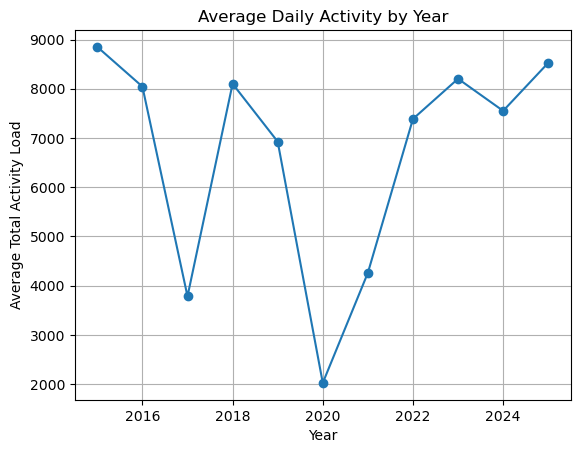

In [171]:
# Create our first EDA chart

import matplotlib.pyplot as plt

yearly_activity.plot(kind="line", marker="o")

plt.title("Average Daily Activity by Year")
plt.xlabel("Year")
plt.ylabel("Average Total Activity Load")
plt.grid()
plt.show()

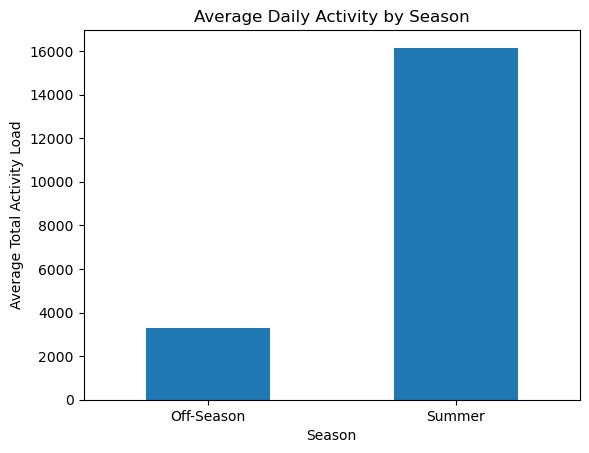

In [172]:
# Seasonal comparison chart

seasonal_activity = daily_df.groupby("Season")["Total Activity Load"].mean()

seasonal_activity.plot(kind="bar")

plt.title("Average Daily Activity by Season")
plt.xlabel("Season")
plt.ylabel("Average Total Activity Load")
plt.xticks(rotation=0)
plt.show()

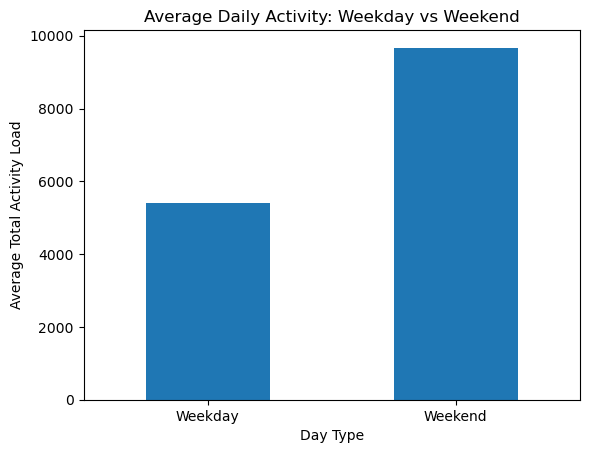

In [173]:
# Weekday vs Weekend visualization

daytype_activity.plot(kind="bar")

plt.title("Average Daily Activity: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Total Activity Load")
plt.xticks(rotation=0)
plt.show()

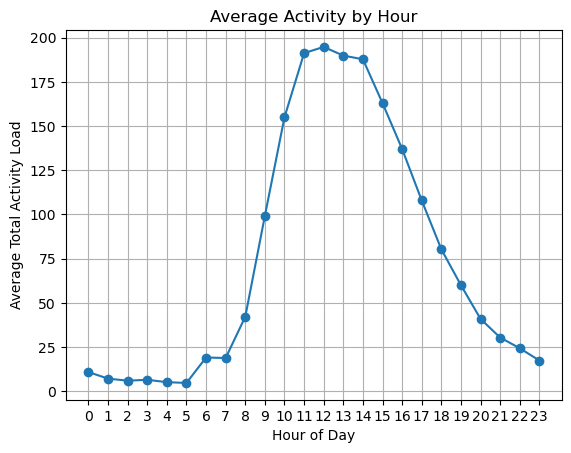

In [174]:
# Hourly activity pattern

hourly_activity.plot(kind="line", marker="o")

plt.title("Average Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Activity Load")
plt.xticks(range(0, 24))
plt.grid()
plt.show()

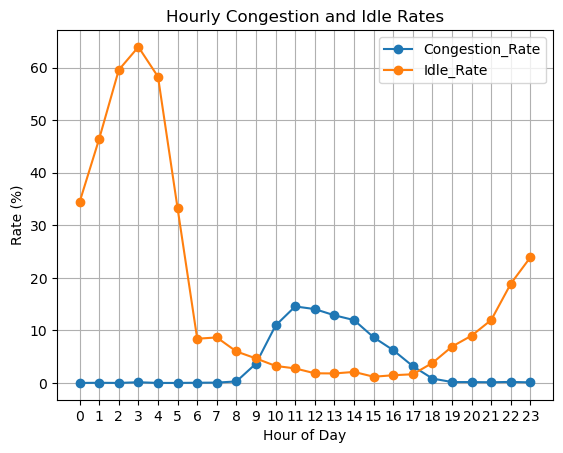

In [175]:
# Congestion vs Idle hourly chart

hourly_operational_pattern[
    ["Congestion_Rate", "Idle_Rate"]
].plot(kind="line", marker="o")

plt.title("Hourly Congestion and Idle Rates")
plt.xlabel("Hour of Day")
plt.ylabel("Rate (%)")
plt.xticks(range(0, 24))
plt.grid()
plt.show()

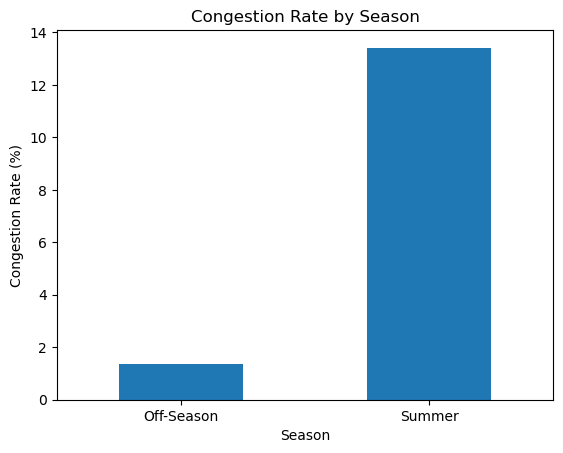

In [176]:
# Seasonal congestion comparison

congestion_season_rate = (
    analysis_df.groupby("Season")["Congestion"].mean() * 100
)

congestion_season_rate.plot(kind="bar")

plt.title("Congestion Rate by Season")
plt.xlabel("Season")
plt.ylabel("Congestion Rate (%)")
plt.xticks(rotation=0)
plt.show()

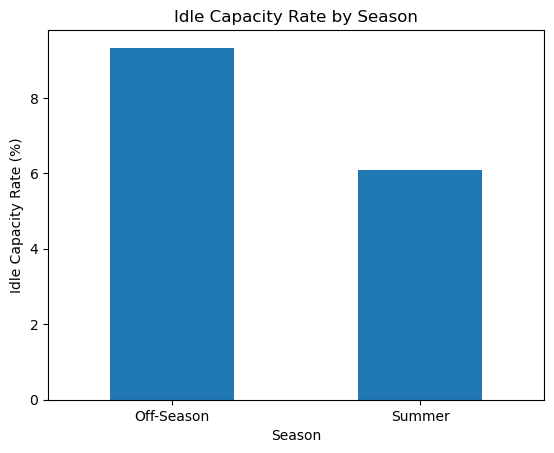

In [177]:
# Seasonal idle-capacity comparison

idle_season_rate = (
    analysis_df.groupby("Season")["Idle Capacity"].mean() * 100
)

idle_season_rate.plot(kind="bar")

plt.title("Idle Capacity Rate by Season")
plt.xlabel("Season")
plt.ylabel("Idle Capacity Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [178]:
# Weekday vs Weekend congestion & idle rates

daytype_operational = analysis_df.groupby("DayType").agg(
    Congestion_Rate=("Congestion", "mean"),
    Idle_Rate=("Idle Capacity", "mean")
) * 100

daytype_operational

,Congestion_Rate,Idle_Rate
DayType,,
Weekday,3.201995,7.757158
Weekend,9.538659,9.814366


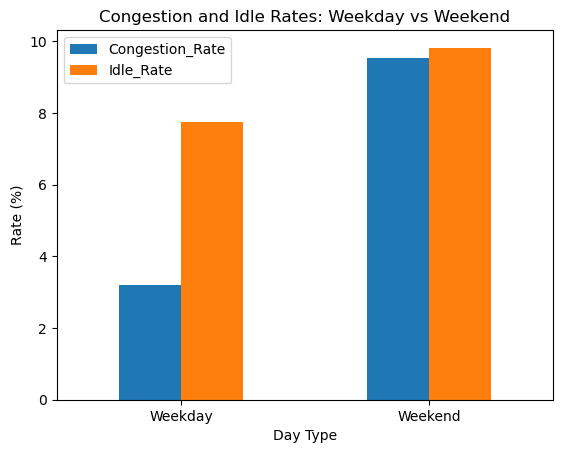

In [179]:
daytype_operational.plot(kind="bar")

plt.title("Congestion and Idle Rates: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [180]:
# Create the congestion heatmap data

congestion_heatmap = (
    analysis_df[analysis_df["Congestion"]]
    .groupby(["DayOfWeek", "Hour"])
    .size()
    .unstack(fill_value=0)
)

congestion_heatmap

Hour,1,3,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
DayOfWeek,,,,,,,,,,,,,,,,,,,,
0,0,0,0,2,5,60,185,307,290,256,213,150,88,44,10,2,1,2,3,3
1,1,0,2,1,7,48,105,188,150,123,87,36,23,12,9,1,3,2,3,1
2,0,0,0,2,10,72,170,241,190,157,119,61,19,9,4,2,1,2,2,1
3,0,2,0,1,5,75,182,234,210,153,116,33,14,6,4,2,2,2,2,1
4,0,0,1,0,10,79,233,270,265,220,199,111,33,15,6,2,5,2,1,1
5,0,0,0,1,3,101,354,468,511,529,524,474,409,228,56,9,8,6,4,1
6,0,0,0,1,1,96,368,460,499,503,502,446,356,161,32,4,1,0,8,3


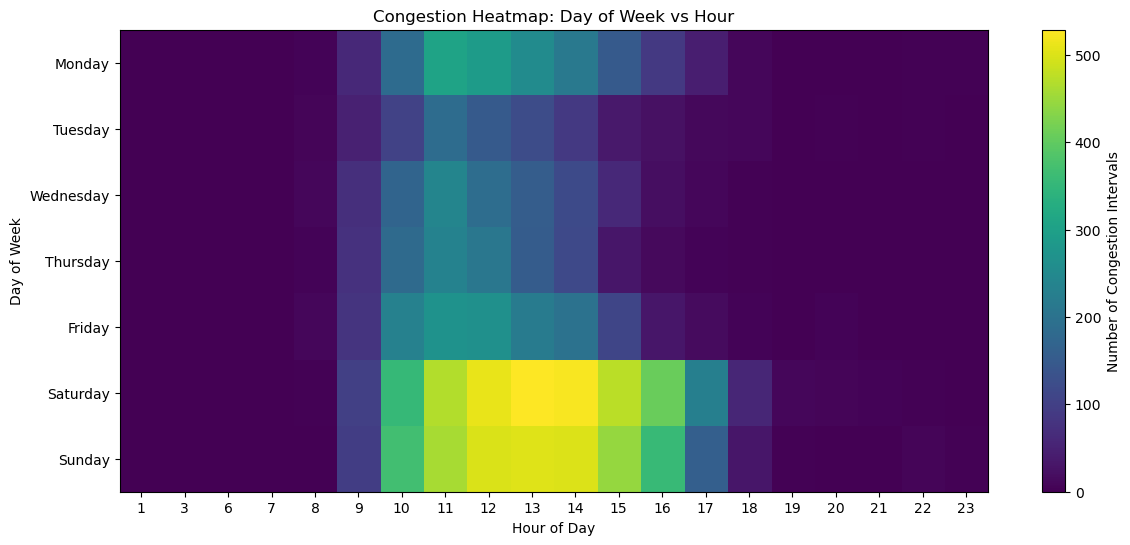

In [181]:
# Create the actual heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.imshow(congestion_heatmap, aspect="auto")

plt.title("Congestion Heatmap: Day of Week vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.xticks(
    range(len(congestion_heatmap.columns)),
    congestion_heatmap.columns
)

plt.yticks(
    range(len(congestion_heatmap.index)),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"]
)

plt.colorbar(label="Number of Congestion Intervals")

plt.show()

In [182]:
# Idle-capacity heatmap

idle_heatmap = (
    analysis_df[analysis_df["Idle Capacity"]]
    .groupby(["DayOfWeek", "Hour"])
    .size()
    .unstack(fill_value=0)
)

idle_heatmap

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
DayOfWeek,,,,,,,,,,,,,,,,,,,,,
0,213,208,177,103,71,57,75,123,119,103,...,46,38,33,42,80,165,196,237,383,410
1,275,204,138,73,42,39,53,106,71,112,...,45,20,31,29,69,136,167,248,347,377
2,229,240,152,81,60,51,64,62,83,108,...,56,17,37,32,83,146,154,227,332,407
3,248,222,166,88,56,36,72,91,90,111,...,47,25,22,29,76,120,165,158,305,347
4,273,297,205,142,108,93,88,152,85,97,...,52,19,25,23,55,108,132,168,255,327
5,268,268,289,254,163,140,194,350,197,44,...,34,23,30,32,79,116,155,194,226,316
6,257,287,323,253,149,130,143,260,218,97,...,28,36,43,59,112,144,209,258,419,337


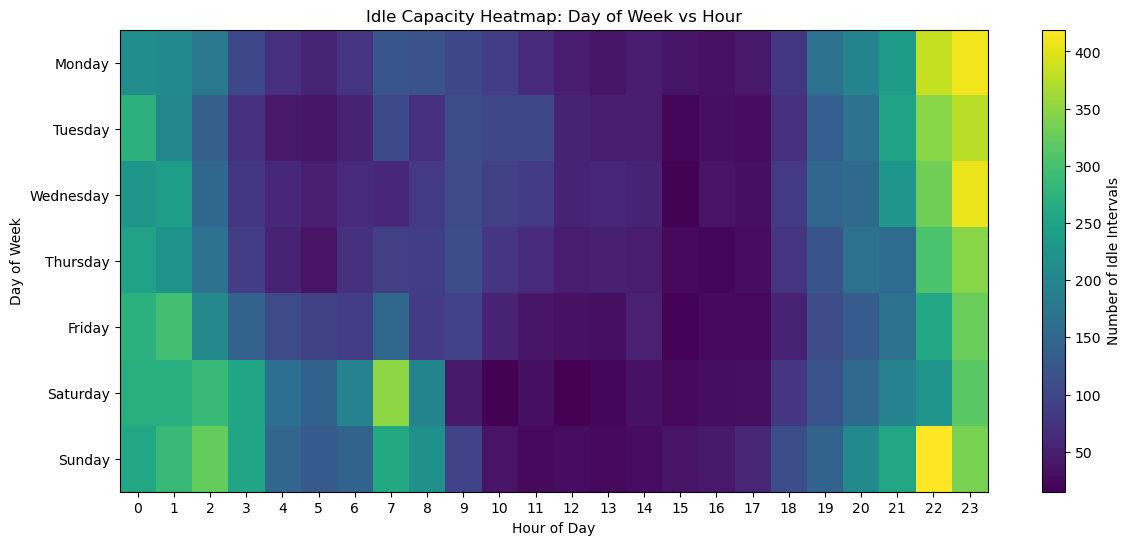

In [183]:
# Create the idle-capacity heatmap

plt.figure(figsize=(14, 6))

plt.imshow(idle_heatmap, aspect="auto")

plt.title("Idle Capacity Heatmap: Day of Week vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.xticks(
    range(len(idle_heatmap.columns)),
    idle_heatmap.columns
)

plt.yticks(
    range(len(idle_heatmap.index)),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"]
)

plt.colorbar(label="Number of Idle Intervals")

plt.show()

In [184]:
# Identify the top congestion hotspots

top_congestion_hotspots = (
    congestion_heatmap
    .stack()
    .sort_values(ascending=False)
    .head(10)
)

top_congestion_hotspots

DayOfWeek  Hour
5          13      529
           14      524
           12      511
6          13      503
           14      502
           12      499
5          15      474
           11      468
6          11      460
           15      446
dtype: int64

In [185]:
# Identify the top idle hotspots

top_idle_hotspots = (
    idle_heatmap
    .stack()
    .sort_values(ascending=False)
    .head(10)
)

top_idle_hotspots

DayOfWeek  Hour
6          22      419
0          23      410
2          23      407
0          22      383
1          23      377
5          7       350
3          23      347
1          22      347
6          23      337
2          22      332
dtype: int64

In [186]:
# Create the final insight summary

final_insights = pd.DataFrame({
    "Metric": [
        "Overall Mean Activity",
        "Overall Mean OLI",
        "Overall Congestion Rate",
        "Overall Idle Rate",
        "Maximum Peak Strain",
        "Busiest Hour",
        "Busiest Time Band",
        "Highest Activity Season",
        "Highest Activity Day Type",
        "Highest Congestion Season",
        "Highest Idle Season"
    ],
    
    "Result": [
        round(analysis_df["Total Activity Load"].mean(), 2),
        round(analysis_df["OLI"].mean(), 4),
        round(analysis_df["Congestion"].mean() * 100, 2),
        round(analysis_df["Idle Capacity"].mean() * 100, 2),
        f"{int(peak_duration_minutes.max())} minutes",
        f"{hourly_activity.idxmax()}:00",
        timeband_activity.idxmax(),
        seasonal_activity.idxmax(),
        daytype_activity.idxmax(),
        congestion_season_rate.idxmax(),
        idle_season_rate.idxmax()
    ]
})

final_insights

,Metric,Result
0,Overall Mean Activity,98.48
1,Overall Mean OLI,0.0067
2,Overall Congestion Rate,5.01
3,Overall Idle Rate,8.34
4,Maximum Peak Strain,585 minutes
5,Busiest Hour,12:00
6,Busiest Time Band,Afternoon
7,Highest Activity Season,Summer
8,Highest Activity Day Type,Weekend
9,Highest Congestion Season,Summer


In [187]:
analysis_df.to_csv("ferry_analysis_data.csv", index=False)

In [188]:
import os

os.path.abspath("ferry_analysis_data.csv")

'C:\\Users\\dharw\\OneDrive\\Documents\\PROJECTS\\unified mentor\\Ferry_Capacity_Analytics\\ferry_analysis_data.csv'